<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/ClusteringAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Analysis

PART 1:


INSTRUCTION:

Use random_state = 42, when applicable
Use MinMaxScaler
Use PCA, 2 components only

Note:
For Hierarchical Clustering use linkage of 'ward'


1. Identify the best clustering model for dataset 'cluster-01.csv'
   (e.g. KMeans, Hierarchical Clustering (HC), Gaussian Mixture Model (GMM))

2. After identification of the best model, according solely to the best silhouette score,
   determine the number of clusters (e.g. 2?, 3? 4?, 5?, 6? 7?, n?)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-01.csv')
df

,x1,x2
0,-2.694898,-1.591274
1,-1.280104,2.124625
2,3.163615,1.798130
3,3.531784,2.654493
4,4.283614,2.070244
...,...,...
995,-0.356843,1.367751
996,0.483930,1.669289
997,2.439531,0.482317
998,1.435149,0.174420


In [ ]:
# Data scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)
df_scaled


,x1,x2
0,0.187660,0.151295
1,0.306736,0.747564
2,0.680741,0.695174
3,0.711728,0.832589
4,0.775006,0.738838
...,...,...
995,0.384442,0.626113
996,0.455206,0.674499
997,0.619799,0.484032
998,0.535265,0.434626


In [ ]:
correlation_matrix = df.corr()

correlation_matrix

,x1,x2
x1,1.000000,0.320117
x2,0.320117,1.000000


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_
components = pca.components_

explained_variance, components

(array([0.66883607, 0.33116393]),
 array([[ 0.81728557,  0.57623284],
        [-0.57623284,  0.81728557]]))

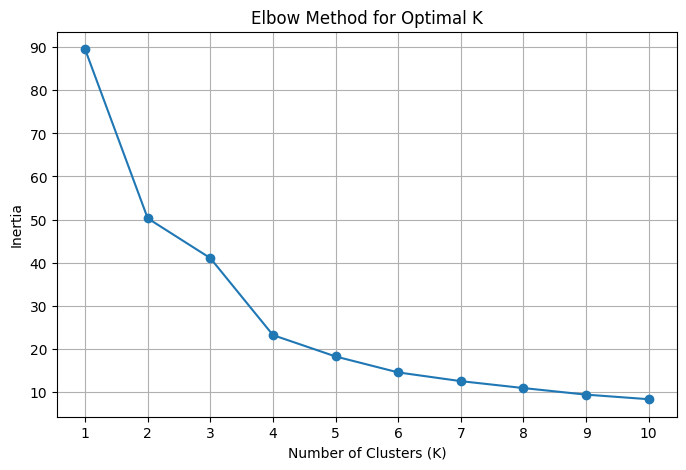

In [ ]:
from sklearn.cluster import KMeans
pca_2_components = PCA(n_components = 2)
data_pca_2_components = pca_2_components.fit_transform(df_scaled)
df_pca_2d = data_pca_2_components[:, :2]

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_pca_2d)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

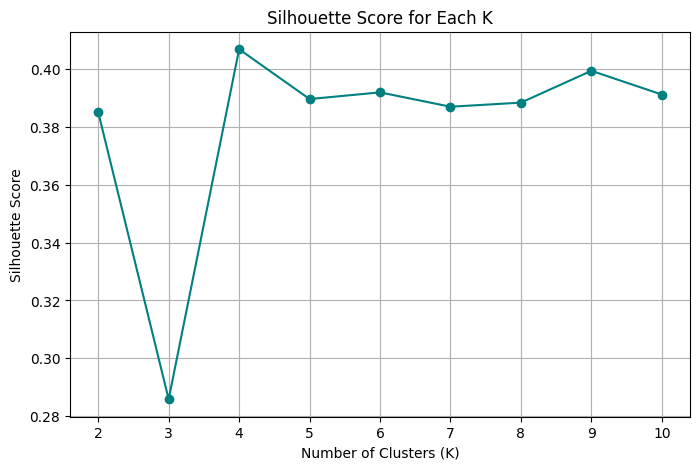

Optimal number of clusters (K): 4
Best silhouette score: 0.40682469866807275


In [ ]:
# KMeans Clustering

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='teal')
plt.title('Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = range(2,11)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"Optimal number of clusters (K): {best_k}")
print(f"Best silhouette score: {best_score:}")


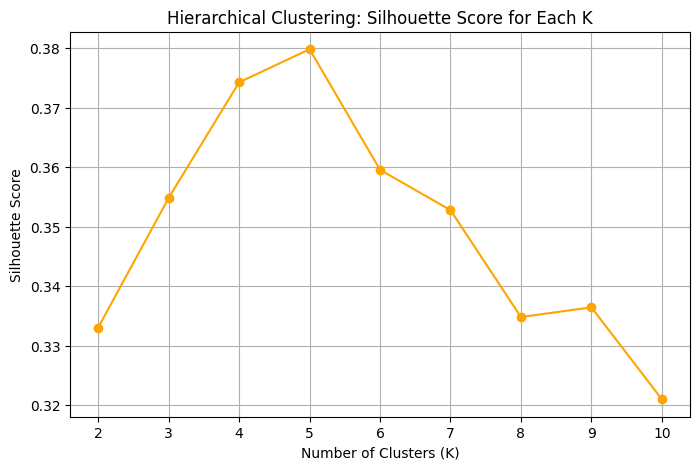

Optimal number of clusters (Hierarchical): 5
Best silhouette score (Hierarchical): 0.3798559275241364


In [ ]:
# Hierarchical Clustering (HC)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores_hc = []

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores_hc.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores_hc, marker='o', color='orange')
plt.title('Hierarchical Clustering: Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_hc = range(2,11)[np.argmax(silhouette_scores_hc)]
best_score_hc = max(silhouette_scores_hc)

print(f"Optimal number of clusters (Hierarchical): {best_k_hc}")
print(f"Best silhouette score (Hierarchical): {best_score_hc:}")


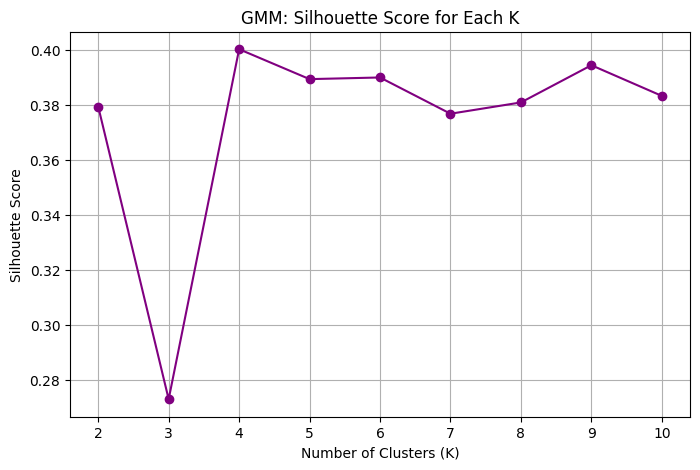

Optimal number of clusters (GMM): 4
Best silhouette score (GMM): 0.40038958758468096


In [ ]:
# Gaussian Mixture Model (GMM)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

silhouette_scores_gmm = []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores_gmm.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores_gmm, marker='o', color='purple')
plt.title('GMM: Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_gmm = range(2,11)[np.argmax(silhouette_scores_gmm)]
best_score_gmm = max(silhouette_scores_gmm)

print(f"Optimal number of clusters (GMM): {best_k_gmm}")
print(f"Best silhouette score (GMM): {best_score_gmm:}")


INSTRUCTION:

Use random_state = 42, when applicable
Use MinMaxScaler
Use PCA, 2 components only

3. Using DBSCAN identify the best epsilon value based on the best silhouette score alone.
   Use dataset 'cluster-04.csv'
   Use the best practice value for the number of minimum samples.

4. How many outliers are detected based from your DBSCAN model?

         V1        V2        V3        V4        V5
0  0.214030  0.100057 -0.887758 -0.280269  0.038000
1 -0.522185  0.974283  0.558264 -0.614753  0.013866
2  0.230652  0.988988  0.016620 -0.224827  0.074689
3  0.140561 -0.111543  0.469752  0.973430 -0.190863
4 -0.741952  0.410469 -0.975351 -0.653820 -0.060877


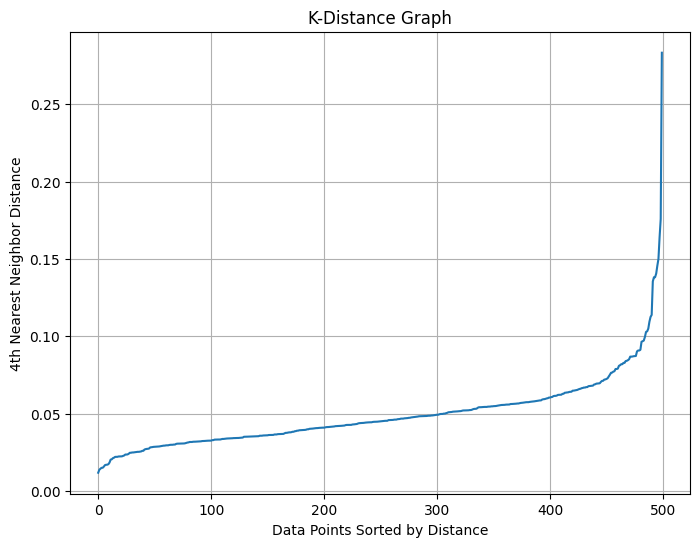

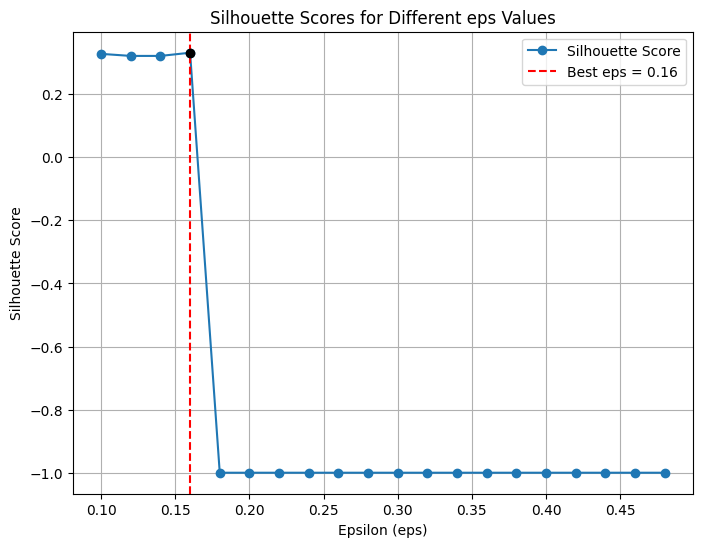

Best epsilon value: 0.16
Best silhouette score: 0.3314
Number of outliers detected: 2


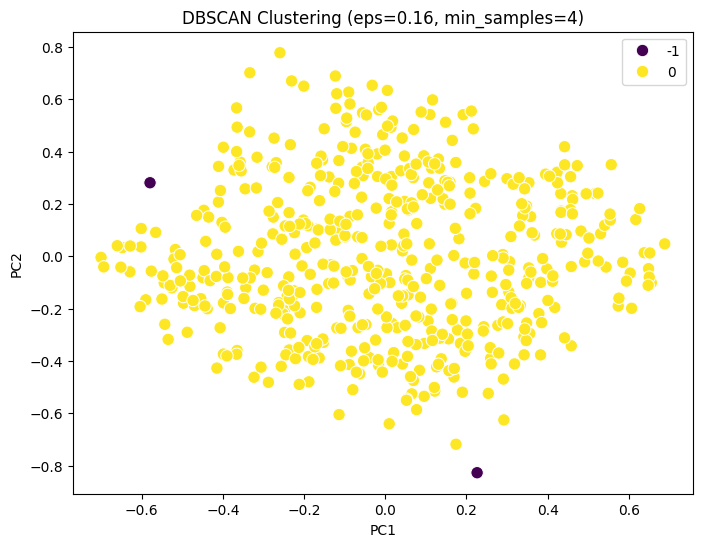

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-04.csv')
print(df.head())

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

pca = PCA(n_components=2, random_state=42)
reduced_df_scaled = pd.DataFrame(pca.fit_transform(scaled), columns=['PC1', 'PC2'])

min_samples = 4
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(reduced_df_scaled)
distances, indices = neighbors_fit.kneighbors(reduced_df_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,6))
plt.plot(k_distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

eps_values = np.arange(0.10, 0.50, 0.02)
s_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(reduced_df_scaled)

    if len(set(labels)) > 1 and len(set(labels)) != 1:
        score = silhouette_score(reduced_df_scaled, labels)
    else:
        score = -1
    s_scores.append(score)

plt.figure(figsize=(8,6))
plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')
best_eps_index = np.argmax(s_scores)
best_eps = eps_values[best_eps_index]
best_s_score = s_scores[best_eps_index]

plt.axvline(x=best_eps, color='r', linestyle='--', label=f'Best eps = {best_eps:.2f}')
plt.scatter(best_eps, best_s_score, color='black', zorder=5)
plt.title('Silhouette Scores for Different eps Values')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

final_model = DBSCAN(eps=best_eps, min_samples=min_samples)
clusters = final_model.fit_predict(reduced_df_scaled)
reduced_df_scaled['Cluster'] = clusters

outliers = np.sum(clusters == -1)
print(f"Best epsilon value: {best_eps:.2f}")
print(f"Best silhouette score: {best_s_score:.4f}")
print(f"Number of outliers detected: {outliers}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=reduced_df_scaled, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=80)
plt.title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={min_samples})')
plt.legend()
plt.show()

PART 2:


For Numbers 5 and 6

INSTRUCTION:

Use random_state = 42, when applicable
Use MinMaxScaler
Use PCA, 2 components only

Note:
For Hierarchical Clustering use linkage of 'ward'


5. Identify the best clustering model for dataset 'cluster-02.csv'
   (e.g. KMeans, Hierarchical Clustering (HC), Gaussian Mixture Model (GMM))

6. After identification of the best model, according solely to the best silhouette score,
   determine the number of clusters (e.g. 2?, 3? 4?, 5?, 6? 7?, n?)


In [ ]:
df_2 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-02.csv')
df_2

,V1,V2,V3,V4,V5
0,4.546780,19.484946,-0.976759,-1.399805,0.642537
1,4.028151,19.709271,-0.855106,-0.701296,0.787845
2,5.280579,20.175870,-0.215013,0.949428,0.550183
3,3.289170,18.632377,-0.040122,-0.095927,1.215803
4,5.336267,20.578907,0.200041,-0.496447,-1.575399
...,...,...,...,...,...
495,36.395168,13.298344,0.095919,-0.261616,-2.626781
496,35.702975,7.860636,-0.091245,1.095519,-2.116182
497,34.872870,8.859035,0.688714,0.407694,-2.952950
498,32.626557,8.308710,-0.803835,1.570093,0.785531


In [ ]:
# Data scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled_2 = scaler.fit_transform(df_2)
df_scaled_2 = pd.DataFrame(df_scaled_2, columns = df_2.columns)
df_scaled_2

,V1,V2,V3,V4,V5
0,0.108471,0.251860,0.006718,0.147549,0.608363
1,0.095585,0.253874,0.067882,0.323031,0.632637
2,0.126704,0.258064,0.389707,0.737732,0.592934
3,0.077224,0.244203,0.477638,0.475114,0.704128
4,0.128087,0.261684,0.598387,0.374494,0.237849
...,...,...,...,...,...
495,0.899789,0.196301,0.546037,0.433489,0.062212
496,0.882590,0.147467,0.451935,0.774433,0.147510
497,0.861965,0.156434,0.844082,0.601636,0.007725
498,0.806152,0.151491,0.093660,0.893658,0.632250


In [ ]:
correlation_matrix = df_2.corr()

correlation_matrix

,V1,V2,V3,V4,V5
V1,1.000000,-0.115446,0.004546,0.000226,0.005324
V2,-0.115446,1.000000,0.027299,0.052394,0.055199
V3,0.004546,0.027299,1.000000,-0.022336,-0.013851
V4,0.000226,0.052394,-0.022336,1.000000,-0.013769
V5,0.005324,0.055199,-0.013851,-0.013769,1.000000


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA()
pca.fit(df_scaled_2)

explained_variance = pca.explained_variance_ratio_
components = pca.components_

explained_variance, components

(array([0.25313307, 0.24550038, 0.23711626, 0.18517622, 0.07907407]),
 array([[ 1.12946531e-02, -7.10904650e-03,  8.71415000e-01,
         -4.75076681e-01, -1.21490477e-01],
        [ 9.00838521e-03, -6.72262140e-04, -2.44788927e-01,
         -6.35933955e-01,  7.31836583e-01],
        [ 3.01757956e-03,  7.26997668e-02,  4.24282452e-01,
          6.06217723e-01,  6.68722747e-01],
        [ 9.90749448e-01, -1.34684945e-01, -5.47992516e-03,
          1.56579043e-02, -5.46062160e-04],
        [ 1.34898874e-01,  9.88192147e-01, -2.58582618e-02,
         -4.63147373e-02, -4.96474594e-02]]))

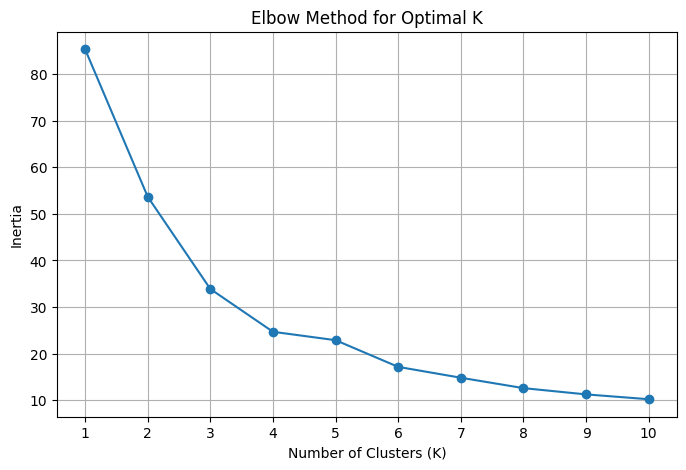

In [ ]:
from sklearn.cluster import KMeans
pca_2_components = PCA(n_components = 2)
data_pca_2_components = pca_2_components.fit_transform(df_scaled_2)
df_pca_2d = data_pca_2_components[:, :2]

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_pca_2d)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

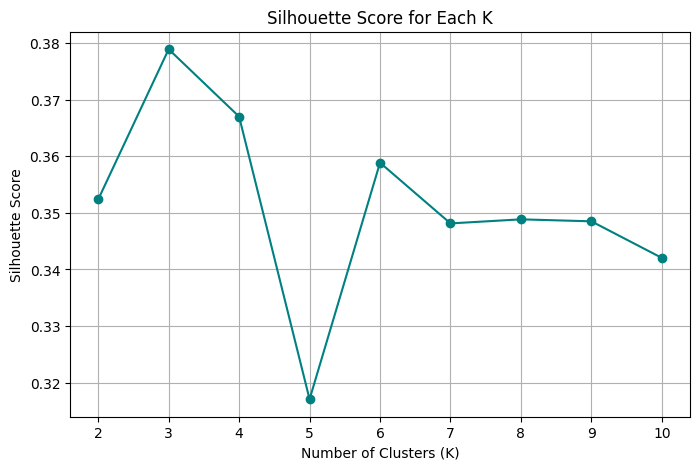

Optimal number of clusters (K): 3
Best silhouette score: 0.378893450987763


In [ ]:
# KMeans Clustering

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='teal')
plt.title('Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = range(2,11)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"Optimal number of clusters (K): {best_k}")
print(f"Best silhouette score: {best_score:}")


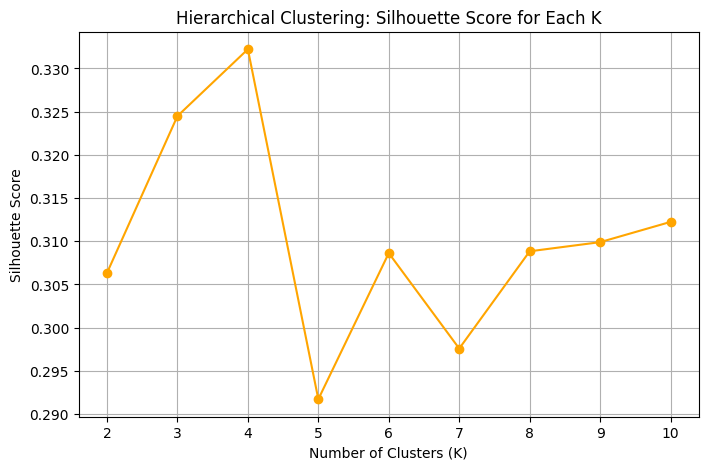

Optimal number of clusters (Hierarchical): 4
Best silhouette score (Hierarchical): 0.3322271444427646


In [ ]:
# Hierarchical Clustering (HC)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores_hc = []

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores_hc.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores_hc, marker='o', color='orange')
plt.title('Hierarchical Clustering: Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_hc = range(2,11)[np.argmax(silhouette_scores_hc)]
best_score_hc = max(silhouette_scores_hc)

print(f"Optimal number of clusters (Hierarchical): {best_k_hc}")
print(f"Best silhouette score (Hierarchical): {best_score_hc:}")


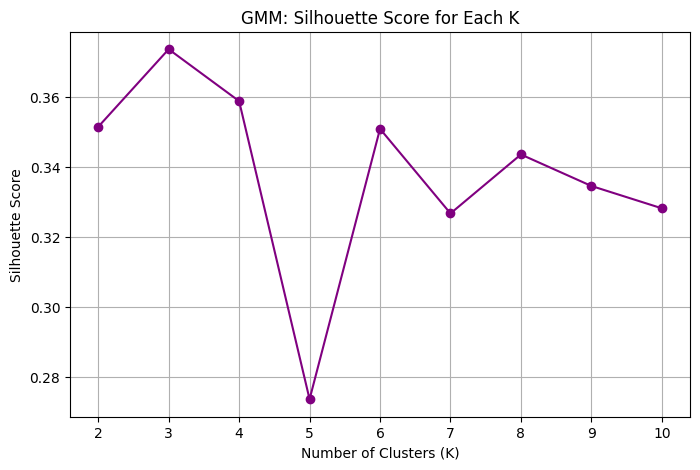

Optimal number of clusters (GMM): 3
Best silhouette score (GMM): 0.37373377711017086


In [ ]:
# Gaussian Mixture Model (GMM)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

silhouette_scores_gmm = []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores_gmm.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores_gmm, marker='o', color='purple')
plt.title('GMM: Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_gmm = range(2,11)[np.argmax(silhouette_scores_gmm)]
best_score_gmm = max(silhouette_scores_gmm)

print(f"Optimal number of clusters (GMM): {best_k_gmm}")
print(f"Best silhouette score (GMM): {best_score_gmm:}")


For Numbers 7 to 8

INSTRUCTION:

Use random_state = 42, when applicable
Use MinMaxScaler
Use PCA, 2 components only

7. Using DBSCAN identify the best epsilon value based on the best silhouette score alone.
   Use dataset 'cluster-05.csv'
   Use the best practice value for the number of minimum samples.

8. How many outliers are detected based from your DBSCAN model?

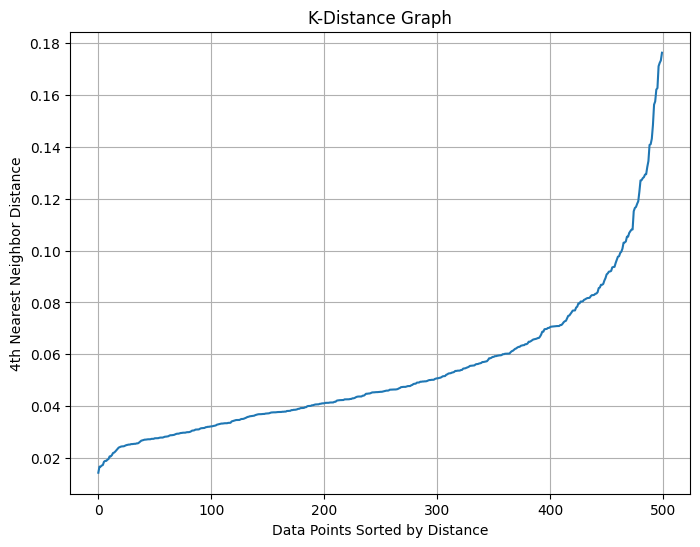

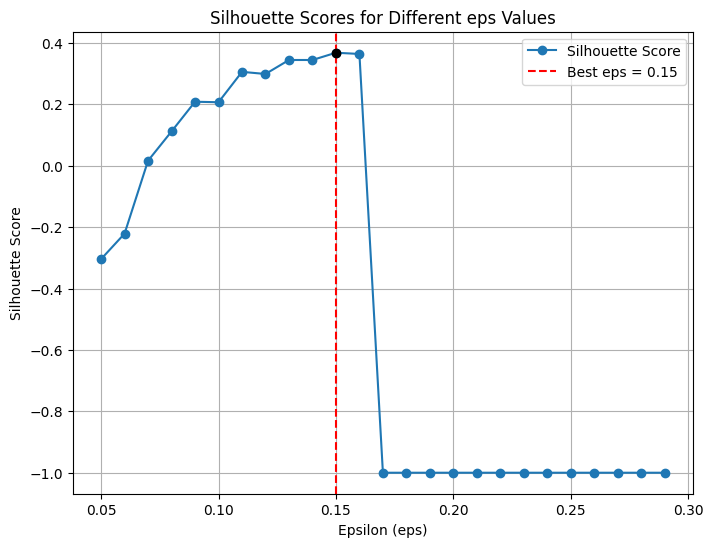

Best epsilon value: 0.15
Best silhouette score: 0.3679
Number of outliers detected: 2


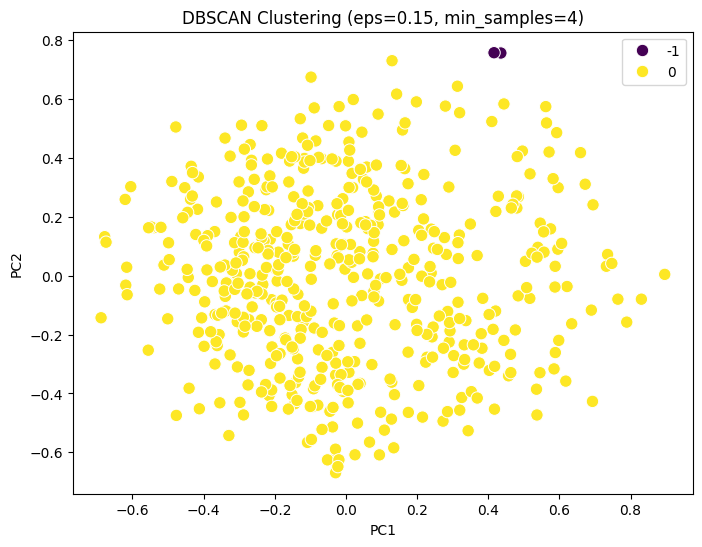

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

df_5 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-05.csv')
df_5

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_5)

pca = PCA(n_components=2, random_state=42)
reduced_df_scaled_5 = pd.DataFrame(pca.fit_transform(scaled), columns=['PC1', 'PC2'])

min_samples = 4
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(reduced_df_scaled_5)
distances, indices = neighbors_fit.kneighbors(reduced_df_scaled_5)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,6))
plt.plot(k_distances)
plt.title('K-Distance Graph')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

eps_values = np.arange(0.05, 0.30, 0.01)
s_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(reduced_df_scaled_5)

    if len(set(labels)) > 1 and len(set(labels)) != 1:
        score = silhouette_score(reduced_df_scaled_5, labels)
    else:
        score = -1
    s_scores.append(score)

plt.figure(figsize=(8,6))
plt.plot(eps_values, s_scores, marker='o', label='Silhouette Score')
best_eps_index = np.argmax(s_scores)
best_eps = eps_values[best_eps_index]
best_s_score = s_scores[best_eps_index]

plt.axvline(x=best_eps, color='r', linestyle='--', label=f'Best eps = {best_eps:.2f}')
plt.scatter(best_eps, best_s_score, color='black', zorder=5)
plt.title('Silhouette Scores for Different eps Values')
plt.xlabel('Epsilon (eps)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()

final_model = DBSCAN(eps=best_eps, min_samples=min_samples)
clusters = final_model.fit_predict(reduced_df_scaled_5)
reduced_df_scaled_5['Cluster'] = clusters

outliers = np.sum(clusters == -1)

print(f"Best epsilon value: {best_eps:.2f}")
print(f"Best silhouette score: {best_s_score:.4f}")
print(f"Number of outliers detected: {outliers}")

plt.figure(figsize=(8,6))
sns.scatterplot(data=reduced_df_scaled_5, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=80)
plt.title(f'DBSCAN Clustering (eps={best_eps:.2f}, min_samples={min_samples})')
plt.legend()
plt.show()


PART 3:


For Numbers 9 and 10

INSTRUCTION:

Use random_state = 42, when applicable
Use MinMaxScaler
Use PCA, 2 components only

Note:
For Hierarchical Clustering use linkage of 'ward'


9. Identify the best clustering model for dataset 'cluster-03.csv'
   (e.g. KMeans, Hierarchical Clustering (HC), Gaussian Mixture Model (GMM))

10. After identification of the best model, according solely to the best silhouette score,
   determine the number of clusters (e.g. 2?, 3? 4?, 5?, 6? 7?, n?)

In [ ]:
df_3 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-03.csv')
df_3

,V1,V2,V3,V4,V5
0,-8.536251,10.944791,6.811667,-5.059278,-3.186717
1,-11.222700,11.844886,5.491410,-5.308275,-4.855787
2,-10.917374,8.133306,6.445988,-5.033128,-8.411694
3,-13.920717,9.838101,7.073802,-6.943141,-5.553332
4,-4.238046,6.763134,4.887413,0.689276,-6.939081
...,...,...,...,...,...
495,0.692156,-8.333670,-2.331047,-1.441930,-1.256196
496,0.678768,-7.006545,-3.909742,-3.714300,-0.383631
497,-5.750153,-10.863700,9.566224,2.342746,4.561322
498,0.745788,-6.620219,-2.037615,-2.184202,-1.432979


In [ ]:
# Data scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled_3 = scaler.fit_transform(df_3)
df_scaled_3 = pd.DataFrame(df_scaled_3, columns = df_3.columns)
df_scaled_3

,V1,V2,V3,V4,V5
0,0.276989,0.925845,0.754206,0.270264,0.362824
1,0.138792,0.960900,0.688772,0.254040,0.270538
2,0.154499,0.816347,0.736082,0.271968,0.073925
3,0.000000,0.882743,0.767198,0.147520,0.231970
4,0.498099,0.762983,0.658837,0.644814,0.155349
...,...,...,...,...,...
495,0.751720,0.175014,0.301079,0.505954,0.469567
496,0.751031,0.226701,0.222836,0.357897,0.517813
497,0.420313,0.076478,0.890726,0.752546,0.791229
498,0.754479,0.241747,0.315622,0.457591,0.459792


In [ ]:
correlation_matrix = df_3.corr()

correlation_matrix

,V1,V2,V3,V4,V5
V1,1.000000,-0.300738,-0.690097,0.190401,0.109136
V2,-0.300738,1.000000,0.407875,-0.222134,-0.794476
V3,-0.690097,0.407875,1.000000,0.181999,-0.001306
V4,0.190401,-0.222134,0.181999,1.000000,0.318842
V5,0.109136,-0.794476,-0.001306,0.318842,1.000000


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA()
pca.fit(df_scaled_3)

explained_variance = pca.explained_variance_ratio_
components = pca.components_

explained_variance, components

(array([0.52703554, 0.25517625, 0.15267759, 0.04738944, 0.01772117]),
 array([[-0.26961647,  0.76735859,  0.27537161, -0.17461816, -0.48181607],
        [-0.54038385, -0.11225657,  0.66819846,  0.30460875,  0.39510515],
        [ 0.45003739,  0.25891786,  0.08102778,  0.84497521, -0.09939459],
        [ 0.55777728,  0.34261459,  0.3435291 , -0.368716  ,  0.56350335],
        [ 0.34877373, -0.46274836,  0.59422517, -0.16366861, -0.53322592]]))

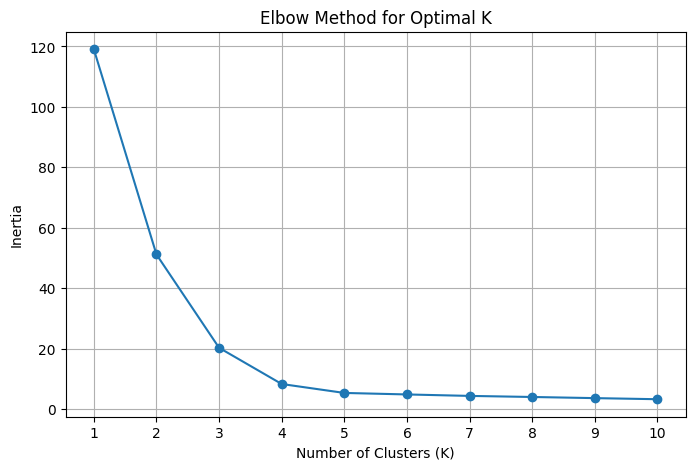

In [ ]:
from sklearn.cluster import KMeans
pca_2_components = PCA(n_components = 2)
data_pca_2_components = pca_2_components.fit_transform(df_scaled_3)
df_pca_2d = data_pca_2_components[:, :2]

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_pca_2d)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

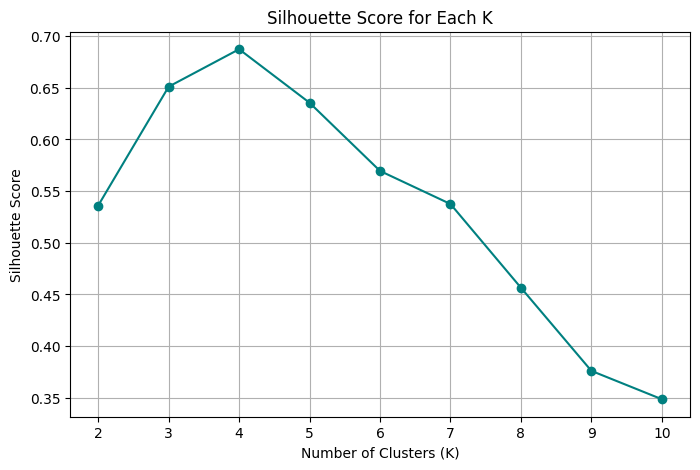

Optimal number of clusters (K): 4
Best silhouette score: 0.6873594296580892


In [ ]:
# KMeans Clustering

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='teal')
plt.title('Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = range(2,11)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"Optimal number of clusters (K): {best_k}")
print(f"Best silhouette score: {best_score:}")


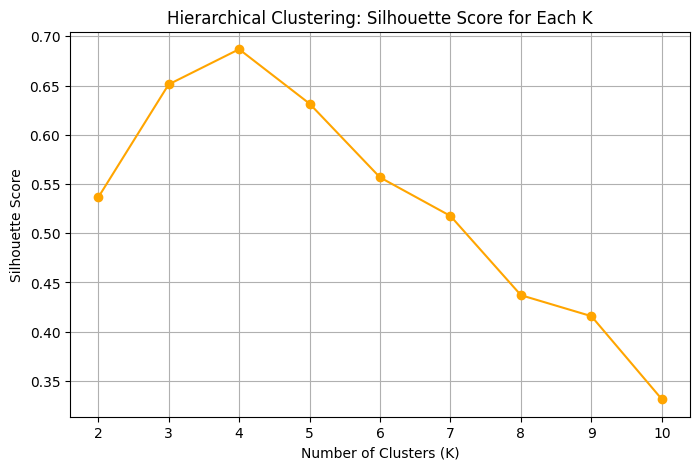

Optimal number of clusters (Hierarchical): 4
Best silhouette score (Hierarchical): 0.6868575056997683


In [ ]:
# Hierarchical Clustering (HC)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_scores_hc = []

for k in range(2, 11):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores_hc.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores_hc, marker='o', color='orange')
plt.title('Hierarchical Clustering: Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_hc = range(2,11)[np.argmax(silhouette_scores_hc)]
best_score_hc = max(silhouette_scores_hc)

print(f"Optimal number of clusters (Hierarchical): {best_k_hc}")
print(f"Best silhouette score (Hierarchical): {best_score_hc:}")


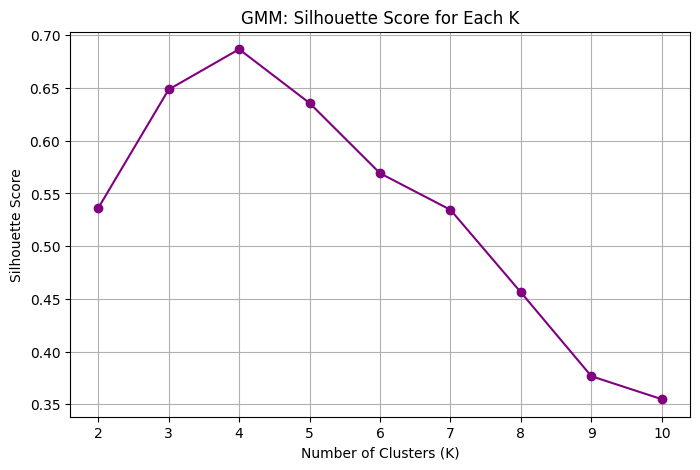

Optimal number of clusters (GMM): 4
Best silhouette score (GMM): 0.6868575056997683


In [ ]:
# Gaussian Mixture Model (GMM)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

silhouette_scores_gmm = []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(df_pca_2d)
    score = silhouette_score(df_pca_2d, labels)
    silhouette_scores_gmm.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores_gmm, marker='o', color='purple')
plt.title('GMM: Silhouette Score for Each K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k_gmm = range(2,11)[np.argmax(silhouette_scores_gmm)]
best_score_gmm = max(silhouette_scores_gmm)

print(f"Optimal number of clusters (GMM): {best_k_gmm}")
print(f"Best silhouette score (GMM): {best_score_gmm:}")


## Conclusion

This notebook performed clustering analysis on three different datasets (`cluster-01.csv`, `cluster-02.csv`, and `cluster-03.csv`) using KMeans, Hierarchical Clustering (HC), Gaussian Mixture Model (GMM), and DBSCAN. The best clustering models and optimal number of clusters were determined based on the silhouette score.

- **For `cluster-01.csv`**: KMeans provided the best silhouette score (0.4068) with 4 clusters.
- **For `cluster-02.csv`**: KMeans provided the best silhouette score (0.3789) with 3 clusters.
- **For `cluster-03.csv`**: KMeans, Hierarchical Clustering, and Gaussian Mixture Model all yielded similar best silhouette scores (around 0.687) with 4 clusters.
- **DBSCAN analysis**: Identified optimal epsilon values and the number of outliers for `cluster-04.csv` and `cluster-05.csv`.